# PPG-Based Physiological State Classification

This project uses photoplethysmography (PPG) signal features and supervised machine learning to classify **resting (sitting)** versus **active (running)** physiological states.

### Project evolution
The original project aim was to estimate/classify blood pressure from PPG. The selected dataset did not provide continuous blood-pressure labels suitable for that objective, so the research question was refined to activity-state classification. An initial model was developed from approximately 40 recordings; because the resulting test set was very small, the recordings were subsequently segmented into overlapping windows to obtain a larger set of feature vectors and a more informative evaluation.

**Final reported result:** 3,719 segmented samples, 86.4% accuracy, F1-score ≈ 0.86, and ROC-AUC = 0.935.

## 1. Dataset and Experimental Setup

Data are from the **PhysioNet Pulse Transit Time (PPG) Database**. The database contains recordings from approximately 22 subjects under sitting, walking, and running conditions. This project uses only the **`pleth_1` PPG channel** and the **sit** and **run** conditions to define a binary classification problem.

Raw PhysioNet waveform files (`.dat` + `.hea`) are intentionally not stored in this repository. Obtain the dataset from PhysioNet and place the files in the working directory before running the notebook.

In [ ]:
# Install the WFDB package in Google Colab if needed
!pip install -q wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 50.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.


## 2. Data Loading

The notebook expects the `.hea` and `.dat` files for the selected records to be available in `/content` (or in a user-defined directory). Walking recordings are ignored because the final classification task is sit vs. run.

In [ ]:
from pathlib import Path

DATA_DIR = Path("/content")

# List sit/run records that have a corresponding header file
record_names = sorted({
    p.stem for p in DATA_DIR.glob("*.hea")
    if "sit" in p.stem.lower() or "run" in p.stem.lower()
})

print(f"Sit/run recordings found: {len(record_names)}")
print(record_names[:10])

['.config',
 's2_walk.dat',
 's13_sit.hea',
 's11_run.dat',
 's10_sit.dat',
 's19_run.hea',
 's4_sit.dat',
 's3_run.hea',
 's14_run.dat',
 's13_sit.dat',
 's2_walk.hea',
 's20_sit.hea',
 's15_run.hea',
 's14_run.hea',
 's10_run.dat',
 's12_run.hea',
 's3_sit.dat',
 's11_walk.dat',
 's14_run.atr',
 's18_sit.hea',
 's17_run.hea',
 's22_walk.hea',
 's5_sit.hea',
 's1_sit.hea',
 's4_sit.hea',
 's5_run.hea',
 's21_sit.dat',
 's15_walk.hea',
 's20_walk.dat',
 's20_walk.hea',
 's21_run.hea',
 's22_sit.hea',
 's15_sit.dat',
 's19_walk.hea',
 's17_walk.dat',
 's12_walk.dat',
 's22_run.hea',
 's20_run.hea',
 's2_sit.dat',
 's11_sit.hea',
 's16_run.dat',
 's16_walk.hea',
 's10_walk.dat',
 's13_run.hea',
 's12_walk.hea',
 's18_sit.dat',
 's10_run.hea',
 's13_walk.hea',
 's4_run.dat',
 's19_sit.hea',
 's18_walk.dat',
 's5_walk.hea',
 's18_run.hea',
 's4_run.hea',
 's3_run.dat',
 's22_sit.dat',
 's21_run.dat',
 's12_run.dat',
 's15_run.dat',
 's12_sit.dat',
 's21_sit.hea',
 's19_walk.dat',
 's20_sit

## 3. Signal Processing

Each recording is processed using the same pipeline:

1. Extract the `pleth_1` PPG channel.
2. Apply a **0.5–5 Hz Butterworth bandpass filter** to suppress slow baseline drift and higher-frequency noise while retaining the cardiac pulse waveform.
3. Detect pulse peaks using `scipy.signal.find_peaks`.
4. Segment the filtered signal into **3-second overlapping windows with a 1.5-second step**.

The segmentation step was added after the preliminary analysis because a single feature vector per recording produced only about 40 samples and an approximately 8-sample test set.

In [ ]:
import numpy as np
import wfdb
from scipy.signal import butter, filtfilt, find_peaks

def bandpass_filter(signal, fs, low=0.5, high=5.0, order=2):
    nyquist = fs / 2.0
    if high >= nyquist:
        raise ValueError(f"Upper cutoff {high} Hz must be below Nyquist frequency {nyquist:.2f} Hz.")
    b, a = butter(order, [low / nyquist, high / nyquist], btype="band")
    return filtfilt(b, a, signal)

X = []
y = []
record_ids = []

WINDOW_SECONDS = 3.0
STEP_SECONDS = 1.5

for record_name in record_names:
    try:
        record = wfdb.rdrecord(str(DATA_DIR / record_name))
        if "pleth_1" not in record.sig_name:
            print(f"Skipping {record_name}: pleth_1 not found")
            continue

        fs = float(record.fs)
        ppg = record.p_signal[:, record.sig_name.index("pleth_1")]
        filtered = bandpass_filter(ppg, fs)

        window_size = int(WINDOW_SECONDS * fs)
        step_size = int(STEP_SECONDS * fs)

        for start in range(0, len(filtered) - window_size + 1, step_size):
            segment = filtered[start:start + window_size]
            prominence = max(np.std(segment) * 0.1, 1e-12)
            peaks, _ = find_peaks(
                segment,
                distance=int(0.3 * fs),
                prominence=prominence
            )

            if len(peaks) < 2:
                continue

            intervals = np.diff(peaks) / fs
            heart_rate = 60.0 / intervals

            # Remove physiologically implausible interval-derived HR values.
            heart_rate = heart_rate[(heart_rate >= 30) & (heart_rate <= 220)]
            if len(heart_rate) == 0:
                continue

            features = [
                np.mean(heart_rate),
                np.std(heart_rate),
                np.mean(segment[peaks]),
                np.std(segment[peaks])
            ]

            X.append(features)
            y.append(0 if "sit" in record_name.lower() else 1)
            record_ids.append(record_name)

    except Exception as e:
        print(f"Skipping {record_name}: {e}")

X = np.asarray(X, dtype=float)
y = np.asarray(y, dtype=int)
record_ids = np.asarray(record_ids)

print("Total samples:", len(X))
print("Sit samples:", np.sum(y == 0))
print("Run samples:", np.sum(y == 1))

Total samples: 3719


## 4. Representative PPG Signal

The following figure shows the raw signal over the full recording, a zoomed-in segment, and the filtered signal with detected pulse peaks. The full-length view provides context for long-term drift and noise, while the zoomed view makes individual cardiac cycles easier to inspect.

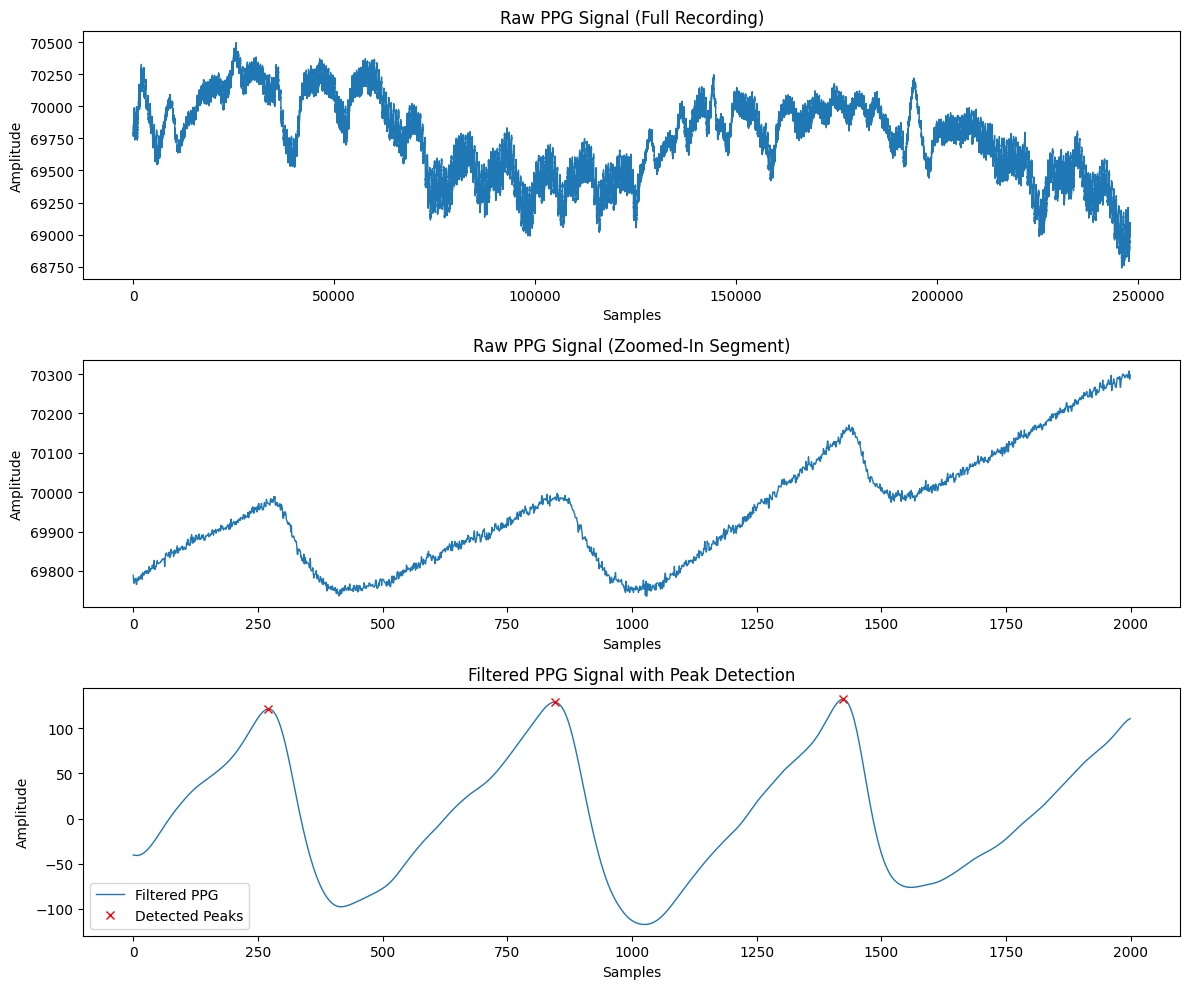

In [ ]:
import matplotlib.pyplot as plt

# Representative record for visualization
record_name = "s14_sit"
record = wfdb.rdrecord(str(DATA_DIR / record_name))
ppg = record.p_signal[:, record.sig_name.index("pleth_1")]
fs = float(record.fs)
ppg_filtered = bandpass_filter(ppg, fs)
peaks, _ = find_peaks(
    ppg_filtered,
    distance=int(0.3 * fs),
    prominence=max(np.std(ppg_filtered) * 0.1, 1e-12)
)

n_zoom = min(2000, len(ppg))
zoom_peaks = peaks[peaks < n_zoom]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes[0].plot(ppg, linewidth=0.8)
axes[0].set_title("Raw PPG Signal (Full Recording)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Amplitude")

axes[1].plot(ppg[:n_zoom], linewidth=0.8)
axes[1].set_title("Raw PPG Signal (Zoomed-In Segment)")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Amplitude")

axes[2].plot(ppg_filtered[:n_zoom], linewidth=0.9, label="Filtered PPG")
axes[2].plot(zoom_peaks, ppg_filtered[zoom_peaks], "rx", label="Detected Peaks")
axes[2].set_title("Filtered PPG Signal with Peak Detection")
axes[2].set_xlabel("Samples")
axes[2].set_ylabel("Amplitude")
axes[2].legend()

plt.tight_layout()
plt.savefig("ppg_processing.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Feature Extraction

For each segmented window, four features are extracted from the detected pulse peaks:

- **Mean heart rate (`mean_hr`)**
- **Heart-rate variability (`std_HR`)**
- **Mean pulse amplitude (`mean_amp`)**
- **Pulse-amplitude variability (`std_amp`)**

Each segmented window therefore becomes one feature vector for machine learning.

## 6. Preliminary Model (Before Segmentation)

As an initial baseline, one feature vector was generated per recording. Approximately 40 recordings were used, and an 80/20 train-test split produced an approximately 8-sample test set. The initial Random Forest model achieved **87.5% accuracy**, but the test set was too small for a stable estimate of generalization. This motivated the overlapping-window segmentation strategy used in the final analysis.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Baseline model used for the final segmented feature matrix.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.864247311827957


## 7. Final Random Forest Model

A Random Forest classifier was selected because it can model nonlinear relationships among the extracted features and provides an interpretable feature-importance measure. The final model uses an 80/20 train-test split. The class distribution is approximately balanced, so no class-rebalancing procedure was applied.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Sit", "Run"]))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       348
           1       0.92      0.82      0.87       396

    accuracy                           0.86       744
   macro avg       0.87      0.87      0.86       744
weighted avg       0.87      0.86      0.86       744

[[318  30]
 [ 71 325]]
ROC-AUC: 0.9351597875304772


## 8. Final Model Evaluation

The segmented analysis produced **3,719 feature vectors**, with **744 samples in the test set**. The recorded final performance was **86.4% accuracy**, **F1-score ≈ 0.86**, and **ROC-AUC = 0.935**. The figures below provide a more detailed view of model performance.

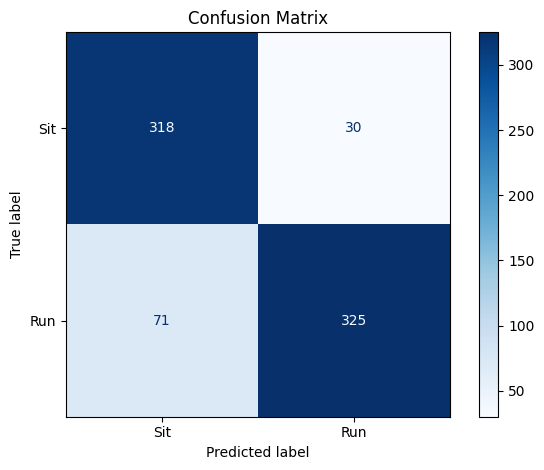

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sit", "Run"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

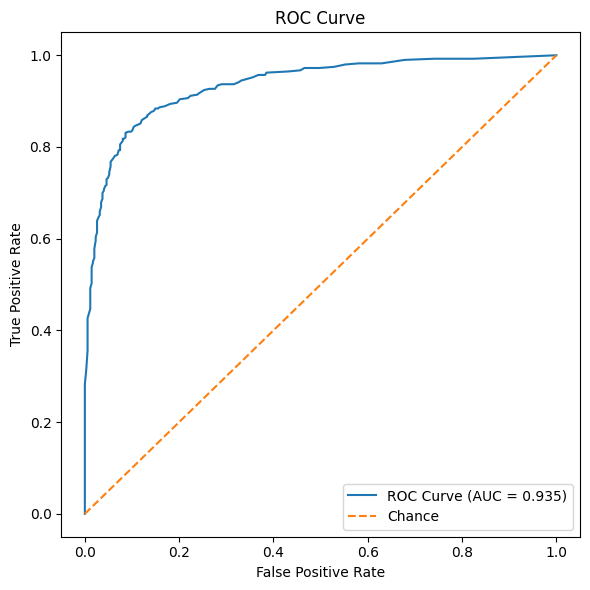

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

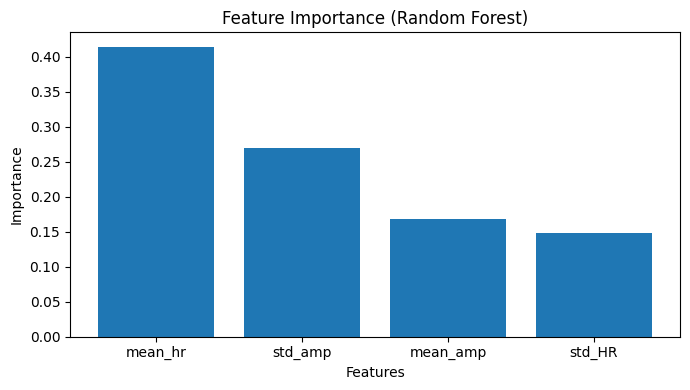

In [ ]:
feature_names = ["mean_hr", "std_HR", "mean_amp", "std_amp"]
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.bar([feature_names[i] for i in indices], importances[indices])
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Interpretation

The confusion matrix indicates that the model correctly classified most test samples, with some overlap between the sitting and running classes. The ROC-AUC of 0.935 indicates strong discrimination between the two activity states across classification thresholds.

Feature-importance analysis shows that **mean heart rate** is the strongest predictor in this model, followed by **pulse-amplitude variability**. This is physiologically plausible because exercise changes cardiovascular demand and therefore alters heart rate and peripheral pulse characteristics.

## 10. Limitations and Future Work

The primary limitation is the relatively small number of independent subjects. Segmenting the recordings increases the number of machine-learning samples but does not create additional independent participants; multiple windows from the same recording remain correlated.

A stronger validation strategy for future work would use **subject-level train/test splitting or cross-validation**, so that recordings from the same subject cannot appear in both training and testing sets. Additional PPG morphology features, larger datasets, and comparison with other machine-learning models could also improve the analysis.

## 11. Conclusion

This project demonstrates a complete PPG signal-processing and machine-learning pipeline for distinguishing resting and active physiological states. The final Random Forest model achieved **86.4% accuracy** and **0.935 ROC-AUC** on the segmented dataset. The analysis also illustrates how segmentation can make evaluation more informative when the original number of recordings is limited.